In [1]:
import loaders
import pandas as pd
import numpy as np

In [2]:
bible = loaders.loader('bible')
references = loaders.loader('clustered_references')
references['ot_loc'] = bible.iloc[references['ostart']].index

In [3]:
rev_refs = references[bible.iloc[references['nstart']]['book'].values == 'Revelation']
bible['referencer'] = False
bible['referencer_0'] = False
bible['referencer_1'] = False
bible['referencer_2'] = False
for start, end, cluster in rev_refs[['nstart', 'nend', 'cluster']].values:
    bible.loc[bible.index[start:end], 'referencer'] = True
    bible.loc[bible.index[start:end], f'referencer_{cluster}'] = True
rev = bible.loc['Revelation']

In [4]:
top_10 = bible['str'].value_counts()[:10].index

In [5]:
for word in top_10:
    rmac = bible.query('str == @word').iloc[0]['rmac']
    print(word, round((bible['str'] == word).sum() * 100/ len(bible), 2), rmac.split('-')[0])

3588 14.3 t
2532 9.2 conj
846 4.56 d
1722 2.25 prep
4771 2.09 p
1473 1.95 p
1519 1.33 a
2962 1.32 n
1510 1.27 v
3739 1.12 r


In [6]:
bible['str'].isin(top_10).sum() / len(bible) * 100

39.378716808744954

<Axes: xlabel='nlen'>

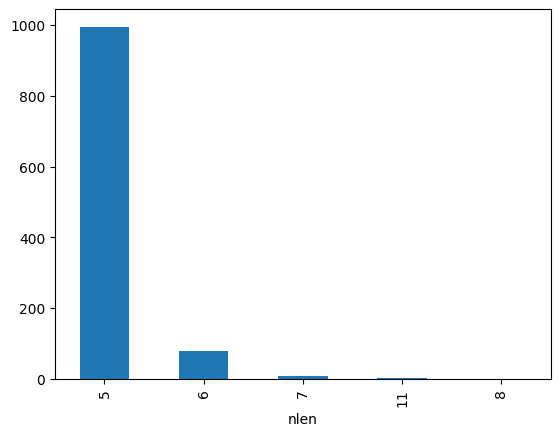

In [7]:
# distribution of reference lengths
rev_refs['nlen'].value_counts().plot.bar()

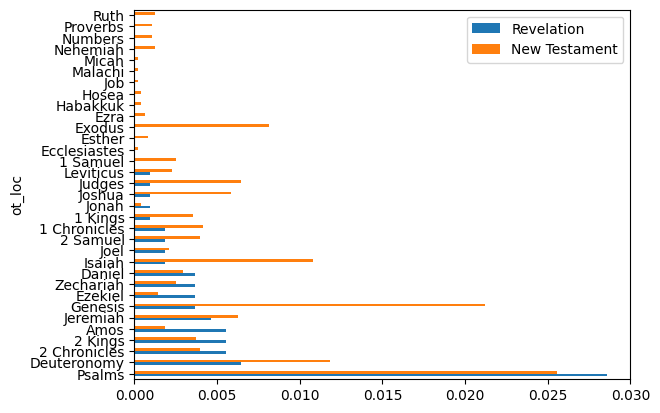

In [8]:
pd.DataFrame({
    'Revelation':rev_refs.query('nlen > 5')['ot_loc'].str[0].value_counts()/len(rev_refs),
    'New Testament':references.query('(nlen > 5)')['ot_loc'].str[0].value_counts()/len(references)
}).sort_values('Revelation', ascending=False).plot.barh();

In [9]:
# proportion of words in revelation that are referencers
rev['referencer'].value_counts()

referencer
False    5226
True     4606
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt

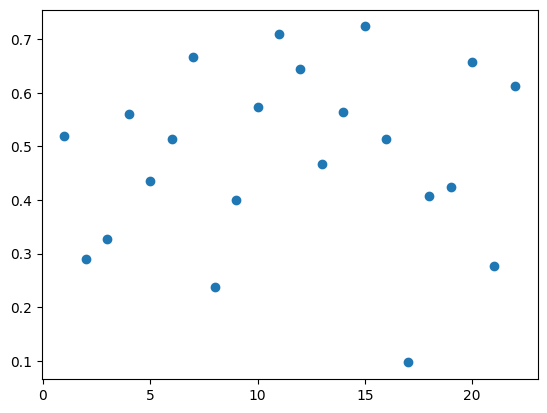

In [17]:
props = rev.groupby(rev['chapter'])['referencer'].apply(lambda g: sum(g)/len(g)).sort_index()
plt.scatter(props.index, props)

/tmp/ipykernel_25666/474203540.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_chapter_props = rev.groupby(rev['chapter']).apply(lambda g: sum(g[name])/len(g)).sort_index()
/tmp/ipykernel_25666/474203540.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_chapter_props = rev.groupby(rev['chapter']).apply(lambda g: sum(g[name])/len(g)).sort_index()
/tmp/ipykernel_25666/474203540.py:4: FutureWarning: DataFr

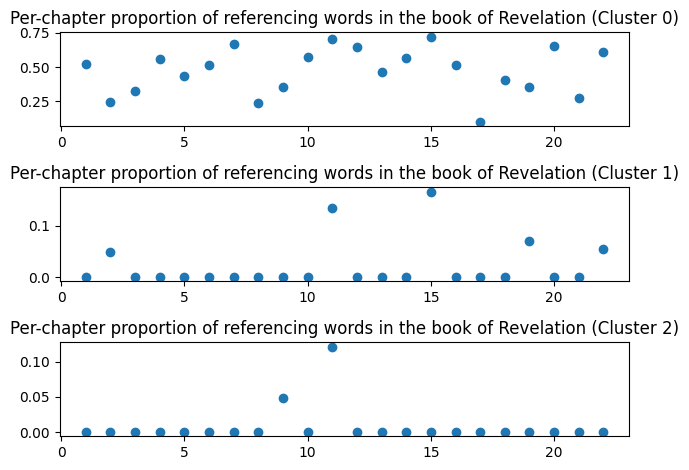

In [24]:
fig, axes = plt.subplots(nrows=3)
for label in range(3):
    name = f'referencer_{label}'
    per_chapter_props = rev.groupby(rev['chapter']).apply(lambda g: sum(g[name])/len(g)).sort_index()
    axes[label].scatter(per_chapter_props.index, per_chapter_props.values)
    axes[label].set_title(f'Per-chapter proportion of referencing words in the book of Revelation (Cluster {label})')
plt.tight_layout()